### 4. Download dataset

You've provided a link to the 'RSNA Bone Age' dataset. Let's download this dataset.

In [1]:
import kagglehub

# Download the 'RSNA Bone Age' dataset
dataset_path = kagglehub.dataset_download('kmader/rsna-bone-age')

print("Path to RSNA Bone Age dataset files:", dataset_path)

Path to RSNA Bone Age dataset files: /kaggle/input/datasets/kmader/rsna-bone-age


Let's list the contents of the downloaded RSNA Bone Age dataset to understand its structure.

In [2]:
#import os

#print("Contents of the RSNA Bone Age dataset:")
#for dirname, _, filenames in os.walk(dataset_path):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

Let's load the `boneage-training-dataset.csv` into a pandas DataFrame and examine its structure.

In [3]:
import pandas as pd
import os

training_csv_path = os.path.join(dataset_path, 'boneage-training-dataset.csv')
train_df = pd.read_csv(training_csv_path)

print("Training DataFrame Info:")
train_df.info()

print("\nFirst 5 rows of Training DataFrame:")
display(train_df.head())

Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12611 entries, 0 to 12610
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       12611 non-null  int64
 1   boneage  12611 non-null  int64
 2   male     12611 non-null  bool 
dtypes: bool(1), int64(2)
memory usage: 209.5 KB

First 5 rows of Training DataFrame:


,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False
3,1380,120,True
4,1381,82,False


Now, let's do the same for the `boneage-test-dataset.csv`.

In [4]:
test_csv_path = os.path.join(dataset_path, 'boneage-test-dataset.csv')
test_df = pd.read_csv(test_csv_path)

print("Test DataFrame Info:")
test_df.info()

print("\nFirst 5 rows of Test DataFrame:")
display(test_df.head())

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Case ID  200 non-null    int64 
 1   Sex      200 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.3+ KB

First 5 rows of Test DataFrame:


,Case ID,Sex
0,4360,M
1,4361,M
2,4362,M
3,4363,M
4,4364,M


### 6. Data Preprocessing
As noted earlier, there are inconsistencies in column names and types between the training and test DataFrames. Let's address these.

In [5]:
import numpy as np

# Harmonize column names and types

# 1. For test_df, rename 'Case ID' to 'id' and 'Sex' to 'male'
test_df = test_df.rename(columns={'Case ID': 'id', 'Sex': 'male'})

# 2. Convert 'male' column in test_df to boolean (True for 'M', False for 'F')
test_df['male'] = test_df['male'].apply(lambda x: True if x == 'M' else False)

# Display updated DataFrames to verify changes
print("Updated Training DataFrame Info:")
train_df.info()
print("\nUpdated Test DataFrame Info:")
test_df.info()

print("\nFirst 5 rows of Updated Training DataFrame:")
display(train_df.head())
print("\nFirst 5 rows of Updated Test DataFrame:")
display(test_df.head())

Updated Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12611 entries, 0 to 12610
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       12611 non-null  int64
 1   boneage  12611 non-null  int64
 2   male     12611 non-null  bool 
dtypes: bool(1), int64(2)
memory usage: 209.5 KB

Updated Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      200 non-null    int64
 1   male    200 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 1.9 KB

First 5 rows of Updated Training DataFrame:


,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False
3,1380,120,True
4,1381,82,False



First 5 rows of Updated Test DataFrame:


,id,male
0,4360,True
1,4361,True
2,4362,True
3,4363,True
4,4364,True


Now that our tabular data is harmonized, let's add the full image paths to both DataFrames. This will allow us to easily load the corresponding X-ray images.

In [6]:
# Create full image paths for training and test data
train_image_dir = os.path.join(dataset_path, 'boneage-training-dataset', 'boneage-training-dataset')
test_image_dir = os.path.join(dataset_path, 'boneage-test-dataset', 'boneage-test-dataset')

train_df['path'] = train_df['id'].apply(lambda x: os.path.join(train_image_dir, f'{x}.png'))
test_df['path'] = test_df['id'].apply(lambda x: os.path.join(test_image_dir, f'{x}.png'))

# Verify that the paths exist and display some examples
print("Example training image path:", train_df['path'].iloc[0])
print("Example test image path:", test_df['path'].iloc[0])

print("\nFirst 5 rows of Training DataFrame with paths:")
display(train_df.head())
print("\nFirst 5 rows of Test DataFrame with paths:")
display(test_df.head())

Example training image path: /kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/1377.png
Example test image path: /kaggle/input/datasets/kmader/rsna-bone-age/boneage-test-dataset/boneage-test-dataset/4360.png

First 5 rows of Training DataFrame with paths:


,id,boneage,male,path
0,1377,180,False,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
1,1378,12,False,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
2,1379,94,False,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
3,1380,120,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
4,1381,82,False,/kaggle/input/datasets/kmader/rsna-bone-age/bo...



First 5 rows of Test DataFrame with paths:


,id,male,path
0,4360,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
1,4361,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
2,4362,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
3,4363,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...
4,4364,True,/kaggle/input/datasets/kmader/rsna-bone-age/bo...


### 7. Image Preprocessing

Now that we have the paths to our images, let's load and preprocess them. This will involve resizing, normalizing pixel values, and preparing them for input into our deep learning model.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions (Increased for better detail capture)
IMG_WIDTH = 384
IMG_HEIGHT = 384
# Reduced batch size to accommodate larger images in GPU memory
BATCH_SIZE = 16

# Create an ImageDataGenerator for training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2], # Adjust brightness for varied X-ray exposures
    horizontal_flip=False, # Removed flip to maintain left-hand orientation
    fill_mode='nearest',
    validation_split=0.2 # Use a portion of training data for validation
)

# Create an ImageDataGenerator for test data (only rescaling)
test_datagen = ImageDataGenerator(
    rescale=1./255  # Normalize pixel values to [0, 1]
)

# Flow from dataframe for training data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='boneage',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw', # For regression tasks
    subset='training',
    seed=42
)

# Flow from dataframe for validation data
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='boneage',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='validation',
    seed=42
)

# Flow from dataframe for test data
# Note: For test data, y_col is typically not available,
# so we use class_mode=None and shuffle=False
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=None, # No labels for the test set
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

print("Image preprocessing setup complete. Generators created for training, validation, and test data.")

2026-06-21 16:19:12.942692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782058753.134651      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782058753.188178      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782058753.650337      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782058753.650383      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782058753.650385      24 computation_placer.cc:177] computation placer alr

Found 10089 validated image filenames.
Found 2522 validated image filenames.
Found 200 validated image filenames.
Image preprocessing setup complete. Generators created for training, validation, and test data.


### 12. Model Improvement: Transfer Learning with ResNet50V2

Using a model pre-trained on ImageNet allows us to leverage complex feature extraction right out of the box. We will freeze the base model initially, or train it with a very low learning rate.

In [8]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, concatenate, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def build_improved_boneage_model(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), gender_input_shape=(1,)):
    # 1. Pre-trained Base Model (Switched to EfficientNetB3)
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Optional: freeze the base model layers (uncomment if you want to train only the top layers first)
    # for layer in base_model.layers:
    #     layer.trainable = False

    # Image input branch
    image_input = Input(shape=input_shape, name='image_input')
    x = base_model(image_input)
    x = GlobalAveragePooling2D()(x) # Better than Flatten for deep networks

    # Gender input branch
    gender_input = Input(shape=gender_input_shape, name='gender_input')

    # Concatenate features
    combined_input = concatenate([x, gender_input])

    # Fully connected layers
    z = Dense(256, activation='relu')(combined_input)
    z = Dropout(0.4)(z)
    z = Dense(128, activation='relu')(z)
    z = Dropout(0.3)(z)

    # Output layer for regression
    output = Dense(1, activation='linear', name='boneage_output')(z)

    # Create the model
    improved_model = Model(inputs=[image_input, gender_input], outputs=output)

    # Compile the model - using a slightly lower learning rate since we are fine-tuning
    improved_model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_absolute_error', metrics=['mean_absolute_error'])

    return improved_model

# Build and view the improved model
improved_model = build_improved_boneage_model()
improved_model.summary()

I0000 00:00:1782058835.075636      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 12, 12,    │ 10,783,535 │ image_input[0][0] │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1537)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ gender_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    393,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boneage_output      │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,210,288 (42.76 MB)

 Trainable params: 11,122,985 (42.43 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks for better training control
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_boneage_model.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Recreate generators to output both 'boneage' and 'male' as targets
train_generator_multi = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col=['boneage', 'male'], # Request both columns
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='training',
    seed=42
)

validation_generator_multi = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col=['boneage', 'male'], # Request both columns
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='validation',
    seed=42
)

# Wrapper generator to split the combined targets into (gender input, boneage target)
def combined_generator(img_gen):
    for img_batch, targets_batch in img_gen:
        # Explicitly cast to float32 to fix the 'object' dtype error
        boneage_batch = targets_batch[:, 0].astype('float32')
        gender_batch = targets_batch[:, 1].astype('float32')

        # Yield a tuple of inputs ((image_batch, gender_batch), boneage_batch)
        yield ((img_batch, gender_batch), boneage_batch)

# Create combined generators for training and validation
train_data_generator = combined_generator(train_generator_multi)
validation_data_generator = combined_generator(validation_generator_multi)

EPOCHS = 50

print("Starting model training...")

history = improved_model.fit(
    train_data_generator,
    steps_per_epoch=train_generator_multi.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_data_generator,
    validation_steps=validation_generator_multi.samples // BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

print("Model training complete.")

Found 10089 validated image filenames.
Found 2522 validated image filenames.
Starting model training...
Epoch 1/50


I0000 00:00:1782058914.450061      67 service.cc:152] XLA service 0x7f4e78003a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782058914.450115      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782058924.296304      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-21 16:22:24.068042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:22:24.265297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:22:24.869218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 37.2657 - mean_absolute_error: 37.2657
Epoch 1: val_loss improved from None to 1032.29553, saving model to best_boneage_model.keras

Epoch 1: finished saving model to best_boneage_model.keras
630/630 ━━━━━━━━━━━━━━━━━━━━ 1153s 2s/step - loss: 24.6659 - mean_absolute_error: 24.6659 - val_loss: 1032.2955 - val_mean_absolute_error: 1032.2955 - learning_rate: 5.0000e-04
Epoch 2/50


2026-06-21 16:40:36.084814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:40:36.278074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:40:36.816672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:40:37.033821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 16:40:37.429795: E external/local_xla/xla/stream_

630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 18.2718 - mean_absolute_error: 18.2718
Epoch 2: val_loss did not improve from 1032.29553
630/630 ━━━━━━━━━━━━━━━━━━━━ 850s 1s/step - loss: 17.6994 - mean_absolute_error: 17.6994 - val_loss: 36548.7656 - val_mean_absolute_error: 36548.7656 - learning_rate: 5.0000e-04
Epoch 3/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - loss: 16.4173 - mean_absolute_error: 16.4173
Epoch 3: val_loss improved from 1032.29553 to 487.73407, saving model to best_boneage_model.keras

Epoch 3: finished saving model to best_boneage_model.keras
630/630 ━━━━━━━━━━━━━━━━━━━━ 762s 1s/step - loss: 16.1587 - mean_absolute_error: 16.1587 - val_loss: 487.7341 - val_mean_absolute_error: 487.7341 - learning_rate: 5.0000e-04
Epoch 4/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - loss: 15.3651 - mean_absolute_error: 15.3651
Epoch 4: val_loss improved from 487.73407 to 63.82961, saving model to best_boneage_model.keras

Epoch 4: finished saving model to best_boneage_model.k

### 9. Visualize Training History
Let's plot the training and validation loss (Mean Absolute Error) to understand how the model learned over time.

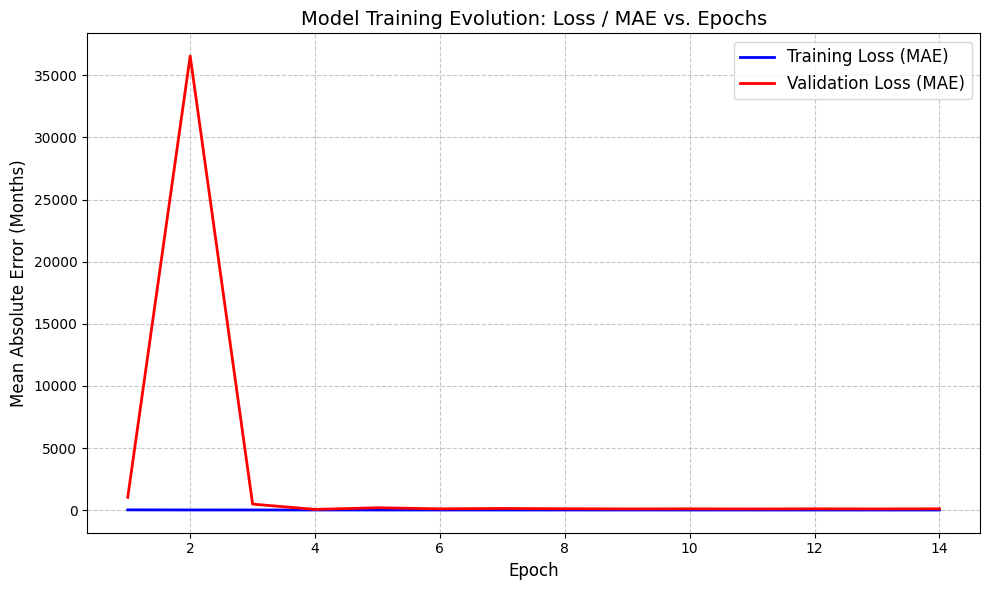

In [10]:
import matplotlib.pyplot as plt

# Extract loss values from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-', label='Training Loss (MAE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MAE)', linewidth=2)

# Formatting the plot
plt.title('Model Training Evolution: Loss / MAE vs. Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Absolute Error (Months)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

### 10. Generate Predictions and Submit

Now we will load the best model weights, generate predictions for the test dataset (providing both the X-ray images and the 'male' boolean flag as inputs), and save the output as `submission.csv`.

### 11. Download Competition Test Data

We need to use the specific test data for the `eliva-25-medical` competition to match the expected 33 rows for submission.

In [11]:
!kaggle competitions download -c eliva-25-medical -p eliva_data
!unzip -q -o eliva_data/eliva-25-medical.zip -d eliva_data

100%|██████████████████████████████████████| 19.3M/19.3M [00:02<00:00, 8.42MB/s]



In [12]:
import os

# List the extracted files to understand the directory structure
print("Contents of eliva_data directory:")
for dirname, _, filenames in os.walk('eliva_data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Contents of eliva_data directory:
eliva_data/eliva-25-medical.zip
eliva_data/test/15.png
eliva_data/test/8.png
eliva_data/test/3.png
eliva_data/test/2.png
eliva_data/test/16.png
eliva_data/test/9.png
eliva_data/test/27.png
eliva_data/test/32.png
eliva_data/test/7.png
eliva_data/test/23.png
eliva_data/test/19.png
eliva_data/test/29.png
eliva_data/test/6.png
eliva_data/test/13.png
eliva_data/test/test.csv
eliva_data/test/5.png
eliva_data/test/4.png
eliva_data/test/31.png
eliva_data/test/26.png
eliva_data/test/22.png
eliva_data/test/28.png
eliva_data/test/18.png
eliva_data/test/25.png
eliva_data/test/30.png
eliva_data/test/20.png
eliva_data/test/17.png
eliva_data/test/12.png
eliva_data/test/1.png
eliva_data/test/24.png
eliva_data/test/21.png
eliva_data/test/10.png
eliva_data/test/11.png
eliva_data/test/14.png
eliva_data/test/33.png


In [13]:
import pandas as pd
import os
import math
import numpy as np
from tensorflow.keras.models import load_model

# Load the competition test set
comp_test_csv = 'eliva_data/test/test.csv'
comp_test_df = pd.read_csv(comp_test_csv)
print("Original Competition Test DataFrame:")
display(comp_test_df.head())

# Standardize columns to 'id' and 'male' (boolean)
if 'Case ID' in comp_test_df.columns:
    comp_test_df = comp_test_df.rename(columns={'Case ID': 'id'})
if 'Sex' in comp_test_df.columns:
    comp_test_df = comp_test_df.rename(columns={'Sex': 'male'})
    comp_test_df['male'] = comp_test_df['male'].apply(lambda x: True if x == 'M' else False)
elif 'gender' in comp_test_df.columns:
    comp_test_df['male'] = comp_test_df['gender'].apply(lambda x: True if str(x).lower() in ['m', 'male'] else False)

# Add full paths
comp_test_image_dir = 'eliva_data/test'
comp_test_df['path'] = comp_test_df['id'].apply(lambda x: os.path.join(comp_test_image_dir, str(x)))

print("\nProcessed Competition Test DataFrame:")
display(comp_test_df.head())

# Create a new generator for the 33 competition images
comp_test_generator = test_datagen.flow_from_dataframe(
    dataframe=comp_test_df,
    x_col='path',
    y_col=None,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

# Manually prepare the dual inputs for model.predict
print("\nPreparing inputs and generating predictions...")

# Get the images from the generator using standard iterator next()
comp_test_generator.reset()
all_images = []
for i in range(math.ceil(comp_test_generator.samples / BATCH_SIZE)):
    batch = next(comp_test_generator)
    all_images.append(batch)
x_images = np.vstack(all_images)

# Get the gender input
x_gender = comp_test_df['male'].values.astype('float32')

# Load the best model saved during training
print("Loading the best trained model...")
best_model = load_model('best_boneage_model.keras')

# Generate predictions using the loaded BEST model (not the untrained 'model')
comp_predictions = best_model.predict([x_images, x_gender])

# Create the final submission DataFrame
comp_submission_df = pd.DataFrame({
    'id': comp_test_df['id'],
    'boneage': comp_predictions.flatten()
})

comp_submission_file = 'eliva_submission.csv'
comp_submission_df.to_csv(comp_submission_file, index=False)
print(f"\nSaved final submission to {comp_submission_file}")
display(comp_submission_df.head())


Original Competition Test DataFrame:


,id,male
0,1.png,False
1,2.png,False
2,3.png,True
3,4.png,False
4,5.png,False



Processed Competition Test DataFrame:


,id,male,path
0,1.png,False,eliva_data/test/1.png
1,2.png,False,eliva_data/test/2.png
2,3.png,True,eliva_data/test/3.png
3,4.png,False,eliva_data/test/4.png
4,5.png,False,eliva_data/test/5.png


Found 33 validated image filenames.

Preparing inputs and generating predictions...
Loading the best trained model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 14s/step

Saved final submission to eliva_submission.csv


,id,boneage
0,1.png,77.221786
1,2.png,85.716995
2,3.png,108.596603
3,4.png,86.556641
4,5.png,163.866043


Finally, we can submit directly to the Kaggle competition using the Kaggle CLI.

In [14]:
!kaggle competitions submit -c eliva-25-medical -f eliva_submission.csv -m "Final 33-row submission"

100%|████████████████████████████████████████████| 553/553 [00:01<00:00, 370B/s]
Successfully submitted to ELIVA25-Medical